In [ ]:
import os
import scipy.io as sio
import h5py
import numpy as np
from glob import glob

from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import torch

import glob
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torch.utils.data import DataLoader
import os


import cv2

In [ ]:

# # ✅ Step 2: Import required libraries
# import os
# import scipy.io as sio
# import h5py
# import numpy as np
# from glob import glob

# # ✅ Step 3: Define the conversion function
# def mat_to_h5(mat_path, h5_path):
#     mat = sio.loadmat(mat_path)
#     density = mat['image_info'][0, 0][0, 0][1]  # Specific to ShanghaiTech format
#     with h5py.File(h5_path, 'w') as hf:
#         hf.create_dataset('density', data=density)

# # ✅ Step 4: Define dataset root directory
# root_dir = "/content/drive/MyDrive/datasets/ShanghaiTech"

# # ✅ Step 5: Convert all .mat files (train and test) in-place
# for split in ['train_data', 'test_data']:
#     gt_dir = os.path.join(root_dir, split, 'ground-truth')
#     mat_files = glob(os.path.join(gt_dir, 'GT_IMG_*.mat'))

#     print(f"\n📂 Processing {len(mat_files)} files in {gt_dir}")

#     for mat_path in mat_files:
#         h5_path = mat_path.replace('.mat', '.h5')  # Save next to .mat file
#         if not os.path.exists(h5_path):  # Only create if it doesn't already exist
#             mat_to_h5(mat_path, h5_path)
#             print(f"✅ Converted: {os.path.basename(mat_path)} → {os.path.basename(h5_path)}")
#         else:
#             print(f"⚠️ Already exists: {os.path.basename(h5_path)}")

# print("\n🎉 All .mat files successfully converted to .h5.")



📂 Processing 400 files in /content/drive/MyDrive/datasets/ShanghaiTech/train_data/ground-truth
✅ Converted: GT_IMG_250.mat → GT_IMG_250.h5
✅ Converted: GT_IMG_104.mat → GT_IMG_104.h5
✅ Converted: GT_IMG_134.mat → GT_IMG_134.h5
✅ Converted: GT_IMG_38.mat → GT_IMG_38.h5
✅ Converted: GT_IMG_125.mat → GT_IMG_125.h5
✅ Converted: GT_IMG_234.mat → GT_IMG_234.h5
✅ Converted: GT_IMG_160.mat → GT_IMG_160.h5
✅ Converted: GT_IMG_108.mat → GT_IMG_108.h5
✅ Converted: GT_IMG_363.mat → GT_IMG_363.h5
✅ Converted: GT_IMG_66.mat → GT_IMG_66.h5
✅ Converted: GT_IMG_205.mat → GT_IMG_205.h5
✅ Converted: GT_IMG_95.mat → GT_IMG_95.h5
✅ Converted: GT_IMG_235.mat → GT_IMG_235.h5
✅ Converted: GT_IMG_52.mat → GT_IMG_52.h5
✅ Converted: GT_IMG_69.mat → GT_IMG_69.h5
✅ Converted: GT_IMG_124.mat → GT_IMG_124.h5
✅ Converted: GT_IMG_181.mat → GT_IMG_181.h5
✅ Converted: GT_IMG_395.mat → GT_IMG_395.h5
✅ Converted: GT_IMG_237.mat → GT_IMG_237.h5
✅ Converted: GT_IMG_39.mat → GT_IMG_39.h5
✅ Converted: GT_IMG_256.mat → GT_IMG

In [ ]:
import h5py
from PIL import Image
import torch
from torchvision import transforms

class CrowdDataset(torch.utils.data.Dataset):
    def __init__(self, img_paths, gt_paths, transform=None):
        self.img_paths = img_paths
        self.gt_paths = gt_paths
        self.transform = transform
        self.gt_transform = transforms.Resize((256, 256))

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        gt_path = self.gt_paths[idx]
        with h5py.File(gt_path, 'r') as f:
            density_map = f['density'][:]

        H_orig, W_orig = density_map.shape
        density_map_img = Image.fromarray(density_map)
        density_map_resized = self.gt_transform(density_map_img)
        density_map_resized = torch.from_numpy(np.array(density_map_resized)).float()
        scale_factor = (H_orig * W_orig) / (256 * 256)
        density_map_resized *= scale_factor
        density_map_resized = density_map_resized.unsqueeze(0)

        return img, density_map_resized


In [ ]:
class CrowdDataset(Dataset):
    def __init__(self, image_paths, gt_paths, transform=None):
        self.image_paths = image_paths
        self.gt_paths = gt_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
      img = Image.open(self.image_paths[idx]).convert('RGB')
      if self.transform:
          img = self.transform(img)

      # Load density map from .h5 file
      with h5py.File(self.gt_paths[idx], 'r') as f:
          density = np.array(f['density'])

      # Resize density map to match model output size (256x256)
      density_resized = cv2.resize(density, (256, 256), interpolation=cv2.INTER_LINEAR)

      # Convert to tensor and add channel dim
      density_tensor = torch.from_numpy(density_resized).unsqueeze(0).float()

      return img, density_tensor


In [ ]:
from glob import glob

train_h5 = glob("/content/drive/MyDrive/datasets/ShanghaiTech/train_data/ground-truth/*.h5")
test_h5 = glob("/content/drive/MyDrive/datasets/ShanghaiTech/test_data/ground-truth/*.h5")

print("Train .h5 files:", len(train_h5))
print("Test .h5 files:", len(test_h5))


Train .h5 files: 400
Test .h5 files: 326


In [ ]:
import os
import glob  # make sure this is fresh

train_img_paths = sorted(glob.glob(os.path.join(root_dir, 'train_data/images/*.jpg')))
# train_gt_paths = sorted(glob.glob(os.path.join(root_dir, 'train_data/ground-truth-h5/*.h5')))
val_img_paths = sorted(glob.glob(os.path.join(root_dir, 'test_data/images/*.jpg')))
# val_gt_paths = sorted(glob.glob(os.path.join(root_dir, 'test_data/ground-truth-h5/*.h5')))
import glob

train_gt_paths = sorted(glob.glob("/content/drive/MyDrive/datasets/ShanghaiTech/train_data/ground-truth/*.h5"))
val_gt_paths = sorted(glob.glob("/content/drive/MyDrive/datasets/ShanghaiTech/test_data/ground-truth/*.h5"))

# Resize to reduce computation
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    # (optional) normalize
])


train_dataset = CrowdDataset(train_img_paths, train_gt_paths, transform)
val_dataset = CrowdDataset(val_img_paths, val_gt_paths, transform)

print("Train images:", len(train_img_paths))
print("Train GTs:", len(train_gt_paths))
print("Val images:", len(val_img_paths))
print("Val GTs:", len(val_gt_paths))

# Show first few paths
print("Example image path:", train_img_paths[0] if train_img_paths else "None found")
print("Example GT path:", train_gt_paths[0] if train_gt_paths else "None found")


train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)


Train images: 400
Train GTs: 400
Val images: 316
Val GTs: 326
Example image path: /content/drive/MyDrive/datasets/ShanghaiTech/train_data/images/IMG_1.jpg
Example GT path: /content/drive/MyDrive/datasets/ShanghaiTech/train_data/ground-truth/GT_IMG_1.h5


In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)


In [ ]:

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for i, (images, densities) in enumerate(train_loader):
        # print(f"Training?batch {i+1}/{len(train_loader)}")  # DEBUG

        images, densities = images.to(device), densities.to(device)
        outputs = model(images)

        # print(f"Output shape: {outputs.shape}, Target shape: {densities.shape}")  # DEBUG

        loss = criterion(outputs, densities)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        print(f"Batch {i+1} loss: {loss.item():.4f}")  # DEBUG
    return total_loss / len(train_loader)


def evaluate(model, val_loader, device):
    model.eval()
    mae = 0.0
    with torch.no_grad():
        for images, densities in val_loader:
            images, densities = images.to(device), densities.to(device)
            outputs = model(images)
            mae += torch.abs(outputs.sum() - densities.sum()).item()
    return mae / len(val_loader)


In [ ]:
print("Number of training images:", len(train_img_paths))
print("Number of training ground truth:", len(train_gt_paths))
print("Number of validation images:", len(val_img_paths))
print("Number of validation ground truth:", len(val_gt_paths))


Number of training images: 400
Number of training ground truth: 400
Number of validation images: 316
Number of validation ground truth: 326


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet()  # instantiate your model
model = model.to(device)  # move model to GPU or CPU

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    print(f"Starting epoch {epoch+1}/{epochs}")

    # Training
    model.train()
    total_train_loss = 0
    for batch_idx, (images, densities) in enumerate(train_loader, 1):
        images, densities = images.to(device), densities.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, densities)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        # if batch_idx % 10 == 0 or batch_idx == len(train_loader):
            # print(f"  Training batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1} average training loss: {avg_train_loss:.4f}")

    # Validation / Evaluation
    model.eval()
    total_mae = 0
    with torch.no_grad():
        for images, densities in val_loader:
            images, densities = images.to(device), densities.to(device)
            outputs = model(images)
            mae = torch.abs(outputs.sum() - densities.sum()).item()
            total_mae += mae
    avg_mae = total_mae / len(val_loader)
    print(f"Validation MAE after epoch {epoch+1}: {avg_mae:.4f}\n")


Starting epoch 1/10
Epoch 1 average training loss: 17246.3895
Validation MAE after epoch 1: 14770688.8354

Starting epoch 2/10
Epoch 2 average training loss: 20064.6899
Validation MAE after epoch 2: 9834837.5696

Starting epoch 3/10
Epoch 3 average training loss: 12884.4174
Validation MAE after epoch 3: 9685931.2405

Starting epoch 4/10
Epoch 4 average training loss: 12663.9316
Validation MAE after epoch 4: 9560327.8987

Starting epoch 5/10
Epoch 5 average training loss: 10720.5290
Validation MAE after epoch 5: 9758509.5443

Starting epoch 6/10
Epoch 6 average training loss: 10416.4281
Validation MAE after epoch 6: 11262270.5570

Starting epoch 7/10
Epoch 7 average training loss: 9703.1486
Validation MAE after epoch 7: 12082329.8481

Starting epoch 8/10
Epoch 8 average training loss: 9924.6952
Validation MAE after epoch 8: 9539183.5949

Starting epoch 9/10
Epoch 9 average training loss: 9888.8571
Validation MAE after epoch 9: 17017372.2785

Starting epoch 10/10
Epoch 10 average trainin

In [ ]:
def test(model, test_loader, device):
    model.eval()
    total_mae = 0
    with torch.no_grad():
        for idx, (images, densities) in enumerate(test_loader):
            images, densities = images.to(device), densities.to(device)
            outputs = model(images)

            # Calculate MAE for the batch
            mae = torch.abs(outputs.sum() - densities.sum()).item()
            total_mae += mae

            # Print some example predictions and ground truths (first batch only)
            if idx == 0:
                for i in range(min(len(images), 3)):  # show first 3 samples
                    print(f"Sample {i+1} - Predicted count: {outputs[i].sum().item():.2f}, True count: {densities[i].sum().item():.2f}")

    avg_mae = total_mae / len(test_loader)
    print(f"Test MAE: {avg_mae:.4f}")

# Usage:
test(model, val_loader, device)


Sample 1 - Predicted count: 8434972.00, True count: 1507328.00
Sample 2 - Predicted count: 9167492.00, True count: 11862016.00
Sample 3 - Predicted count: 9054106.00, True count: 10289152.00
Test MAE: 11197956.0000


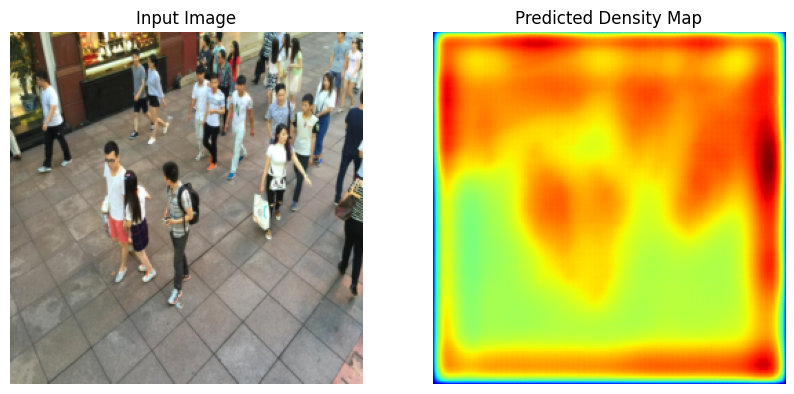

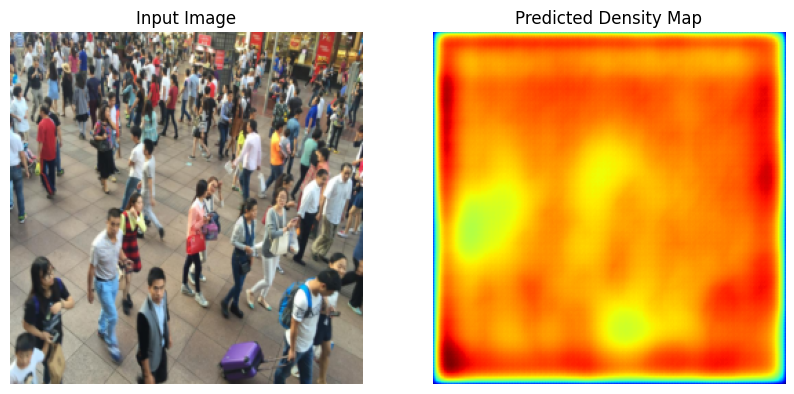

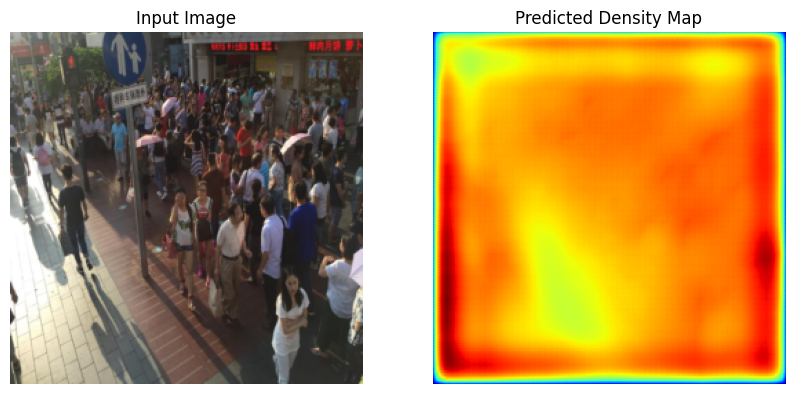

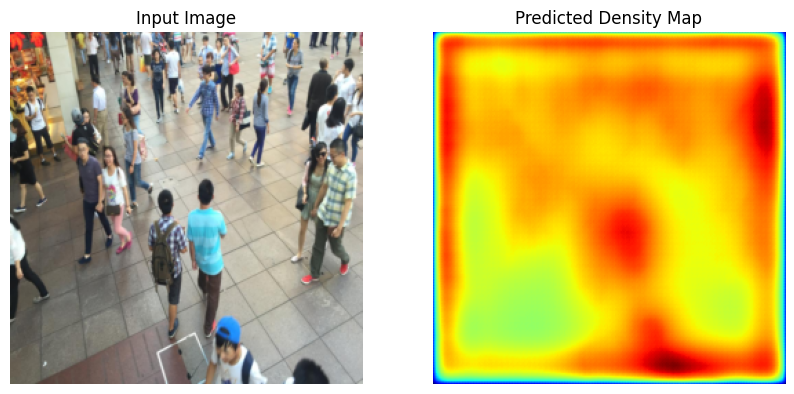

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_prediction(model, test_loader, device, num_images=1):
    model.eval()
    with torch.no_grad():
        for i, (images, densities) in enumerate(test_loader):
            images = images.to(device)
            outputs = model(images)

            # Move outputs and images back to CPU and convert to numpy
            outputs_np = outputs.squeeze(1).cpu().numpy()  # shape: (batch_size, H, W)
            images_np = images.cpu().numpy()  # shape: (batch_size, 3, H, W)

            for j in range(min(num_images, images_np.shape[0])):
                # Original image (transpose CHW to HWC)
                img = np.transpose(images_np[j], (1, 2, 0))
                pred_density = outputs_np[j]

                # Plot image and predicted density map side by side
                fig, axs = plt.subplots(1, 2, figsize=(10, 5))

                axs[0].imshow(img)
                axs[0].set_title("Input Image")
                axs[0].axis('off')

                axs[1].imshow(pred_density, cmap='jet')
                axs[1].set_title("Predicted Density Map")
                axs[1].axis('off')

                plt.show()

            break  # Only show for the first batch

# Usage:
show_prediction(model, val_loader, device, num_images=4)
